In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.research.qcut_analyzer import QcutAnalyzer
# QcutAnalyzer.plot_qcut_analysis(df, col_a='Factor_A', col_b='Return')
from sdk_core import configure
from sdk_core import TwMarketData
# configure()ng

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


/home/kevin/Project/HFT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sdk_core import configure
from sdk_core import TwMarketData
# configure()

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


In [3]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260408.parquet' '20260409.parquet' '20260410.parquet'
 '20260413.parquet' '20260414.parquet']


f = '20260324.parquet'
stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x :x.BidPrice1 > 0]
code = '6547'
seq = 320659
stock_df[lambda x : (x.QuoteCode == code) & (x.ChannelSeq >= seq)].head()

In [4]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[1:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 100
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(6)
        stock_df['ToOpen'] = ((stock_df['BidPrice1'] - stock_df.Open) / stock_df.Open ).round(6)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureLow < stock_df.RefPrice*0.91 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*0.91 - stock_df.TickSize) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > 0) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank_canDayTrade <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

100%|██████████| 785/785 [00:37<00:00, 21.07it/s]


In [5]:
signal_df = pd.concat(data).reset_index(drop=True)

In [6]:
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2023-01-05 09:05:19.105965,1101,363517,2586,34.10,57,34.20,52,34.4,34.7,33.5,34.45,34.15,2.0,-102.639296,0.017910,-550,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
1,2023-01-05 09:05:40.821632,1101,382879,2716,34.05,126,34.15,23,34.4,34.7,33.5,34.45,34.15,2.0,-117.474302,0.016418,-96,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
2,2023-01-05 09:05:40.835442,1101,382902,2716,34.10,20,34.15,31,34.4,34.7,33.5,34.45,34.15,1.0,-102.639296,0.017910,-96,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
3,2023-01-05 09:05:40.847895,1101,382917,2716,34.05,146,34.15,35,34.4,34.7,33.5,34.45,34.15,2.0,-117.474302,0.016418,-96,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
4,2023-01-05 09:05:42.636365,1101,384520,2721,34.10,1,34.15,33,34.4,34.7,33.5,34.45,34.15,1.0,-102.639296,0.017910,-91,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
5,2023-01-05 09:05:45.619713,1101,387113,2723,34.05,146,34.15,33,34.4,34.7,33.5,34.45,34.15,2.0,-117.474302,0.016418,-91,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
6,2023-01-05 09:05:46.323109,1101,387834,2724,34.10,5,34.15,32,34.4,34.7,33.5,34.45,34.15,1.0,-102.639296,0.017910,-90,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
7,2023-01-05 09:06:27.468335,1101,422145,2834,34.15,1,34.20,109,34.4,34.7,33.5,34.45,34.15,1.0,-87.847731,0.019403,-2,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
8,2023-01-05 09:06:29.424356,1101,423695,2836,34.10,138,34.20,109,34.4,34.7,33.5,34.45,34.15,2.0,-102.639296,0.017910,-4,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562
9,2023-01-05 09:06:31.008569,1101,425124,2838,34.15,1,34.20,106,34.4,34.7,33.5,34.45,34.15,1.0,-87.847731,0.019403,-2,122.0,60.0,09:05:00,2023-01-05 09:04:59.636562


In [7]:
# target_time_str = "13:25:00"
# target_dt = pd.to_datetime(signal_df['TransTime'].dt.date.astype(str) + " " + target_time_str)
# signal_df['RemainSeconds'] = (target_dt - signal_df['TransTime']).dt.total_seconds()
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) &(signal_df.TransTime.dt.time > datetime.time(9, 0, 30)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
# signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

In [8]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date
0,2023-01-05 09:05:19.105965,2023-01-05 09:05:19.105965,1101,1101,1035802,363517,0,0,-1,0,2586,34.1,34.05,34.0,33.95,33.9,57,121,226,22,97,34.2,34.25,34.3,34.35,34.4,52,217,187,136,198,34.15,2,0.0,0,0.0,0,NaN,2,33.5,False,True,34.15,34.45,34.4,34.15,34.7,34.05,0.0,0.007463,0.0,-0.05,0.0,0.05,14.662757,34.15,0.01791,-0.001464,-550,-171,-550,0.522936,0.108987,0.340344,0.065823,0.340506,2.0,10,34.2,34.1,1,NaN,0.0,0.905773,-1.0,2,368,25,15580,34.15,34.1,34.15,34.1,34.15,34.1,34.25,34.2,34.25,34.2,34.25,34.2,-102.639296,73.099415,-7.320644,-7.320644,-7.320644,21.961933,-21.961933,21.961933,X,10493097.0,182243.0,592000.0,0.0,-3074323.0,27000.0,284.0,-3.0,X,10413.0,3509.0,3046.0,180.302706,242.571005,2254.0,-0.002234,20.0,-30.012817,3.92992,20.0,18.878836,11.791032,0.036689,-44.565533,-9.29368,29.761905,14.869888,0.193744,-29.761905,0.0,29.761905,29.739777,29.806259,-42.906032,-6.606401,19.135821,-2.127443,-1.653713,-0.998408,17.440131,16.970892,-34.880893,-54.362801,-29.761905,-34.442624,122.0,53.0,2023-01-05 09:04:59.636562,09:05:00,60.0,1779.0,19.0,1796.0,151.0,941.0,47.0,521.0,221.0,343.0,59.0,20230105


<Axes: xlabel='Date'>

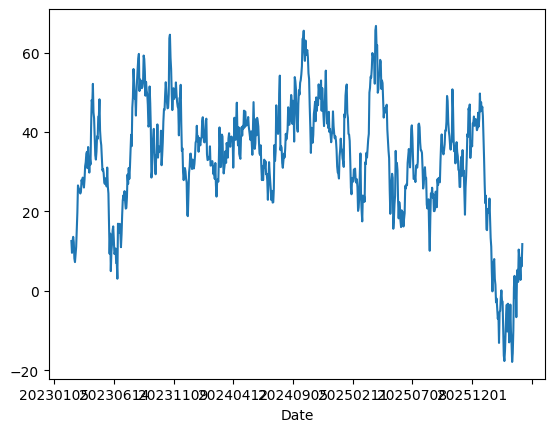

In [9]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [10]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby('Date').TakerSell_CloseBP.transform('mean')

In [11]:
signal_df.TakerSell_CloseBP .describe()

count    6.448173e+06
mean     7.796441e+01
std      2.850727e+02
min     -8.892893e+02
25%     -2.906977e+01
50%      9.803922e+01
75%      2.355072e+02
max      1.423077e+03
Name: TakerSell_CloseBP, dtype: float64

In [12]:
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
condition = condition#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition].TakerSell_CloseBP * signal_df[condition].BidPrice1).sum() / signal_df[condition].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date.astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round((signal_df[condition_recent].TakerSell_CloseBP * signal_df[condition_recent].BidPrice1).sum() / signal_df[condition_recent].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    6.448173e+06
mean     7.796441e+01
std      2.850727e+02
min     -8.892893e+02
25%     -2.906977e+01
50%      9.803922e+01
75%      2.355072e+02
max      1.423077e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 59.45
averge prod num : 72.02
count    813641.000000
mean         34.457576
std         381.291916
min        -878.400000
25%        -200.668896
50%          52.816901
75%         276.243094
max        1422.459893
Name: TakerSell_CloseBP, dtype: float64

cap BP : 2.13
averge prod num : 68.17


In [13]:
signal_df = signal_df[condition].reset_index(drop=True)
# signal_df = signal_df[condition & ((signal_df.Date.astype(int) < 20260101) |( (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )))].reset_index(drop=True)


In [14]:
print(signal_df.columns.tolist())

['RecvTime', 'TransTime', 'QuoteCode', 'ValueCode', 'PacketSeq', 'ChannelSeq', 'LimitStatus', 'TrialMatch', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5', 'BidLots1', 'BidLots2', 'BidLots3', 'BidLots4', 'BidLots5', 'AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5', 'AskLots1', 'AskLots2', 'AskLots3', 'AskLots4', 'AskLots5', 'FillPrice', 'FillLots', 'BestBidPrice', 'BestBidLots', 'BestAskPrice', 'BestAskLots', 'OvershootHis', 'FillLots_origin', 'RefPrice', 'OTC', 'marketOpen', 'Open', 'Close', 'RecordHigh', 'RecordLow', 'FutureHigh', 'FutureLow', 'ToLow', 'ToHigh', 'Low_High', 'BidPreMove', 'AskPreMove', 'TickSize', 'TickBP', 'MidPrice', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'FillLots_Net', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairAsk', 'SpreadPairBid', 'SpreadPairSeq', 'SpreadCountAtSameCount', 'SpreadPairElapsed', 'SpreadNarrowOrderTime', 'Sprea

In [29]:
## 部位留存
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df[ (~((signal_df.PosLots >1) & (signal_df.Position > 15))) & (signal_df.BidPrice1<150)].sort_values(by=['Date', 'TransTime']).reset_index(drop=True)
# signalwithRisk_df = signal_df[  (~((signal_df.PosLots >1) & (signal_df.Position > 200))) & (signal_df.BidPrice1<1000) ].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.PosLots ==1) & (signal_df.BidPrice1 <= 100)].reset_index(drop=True)


In [30]:
signalwithRisk_df.loc[ signalwithRisk_df.FutureLow < signalwithRisk_df.RefPrice*0.91 , 'TakerSell_CloseBP'] = ((signalwithRisk_df[targetLabel] - signalwithRisk_df.RefPrice*0.91 - signalwithRisk_df.TickSize) / signalwithRisk_df[targetLabel] * 10000)

In [31]:
signalwithRisk_df['totalPosition'] = signalwithRisk_df.groupby(['Date']).BidPrice1.transform('cumsum') / 10

signalwithRisk_df = signalwithRisk_df[ (signalwithRisk_df.totalPosition <= 20000 )].reset_index(drop=True)

for d in signalwithRisk_df[lambda x : x.Date.astype(int) == 20260402].Date.unique() :
    signalwithRisk_df[lambda x : x.Date == d].reset_index(drop=True).to_csv(f'{d}_10w.csv')

signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].groupby('QuoteCode').first().sort_values(by='TransTime').reset_index(drop=True)

In [32]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['3702', '3535', '5347', '2492', '2485', '6770', '2344', '1815', '4906',
 '1717', '1711', '3645', '3042', '4908', '2426', '8043', '4919', '2329',
 '1582', '2484', '3481', '5340', '4927']
Length: 23, dtype: str

In [33]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.08) ].QuoteCode.unique()

<ArrowStringArray>
['3042', '4919', '2484']
Length: 3, dtype: str

In [34]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1

# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260414
單邊部位: 266.21 萬
損益: -0.57 萬
排名: 266.0,  33.89%


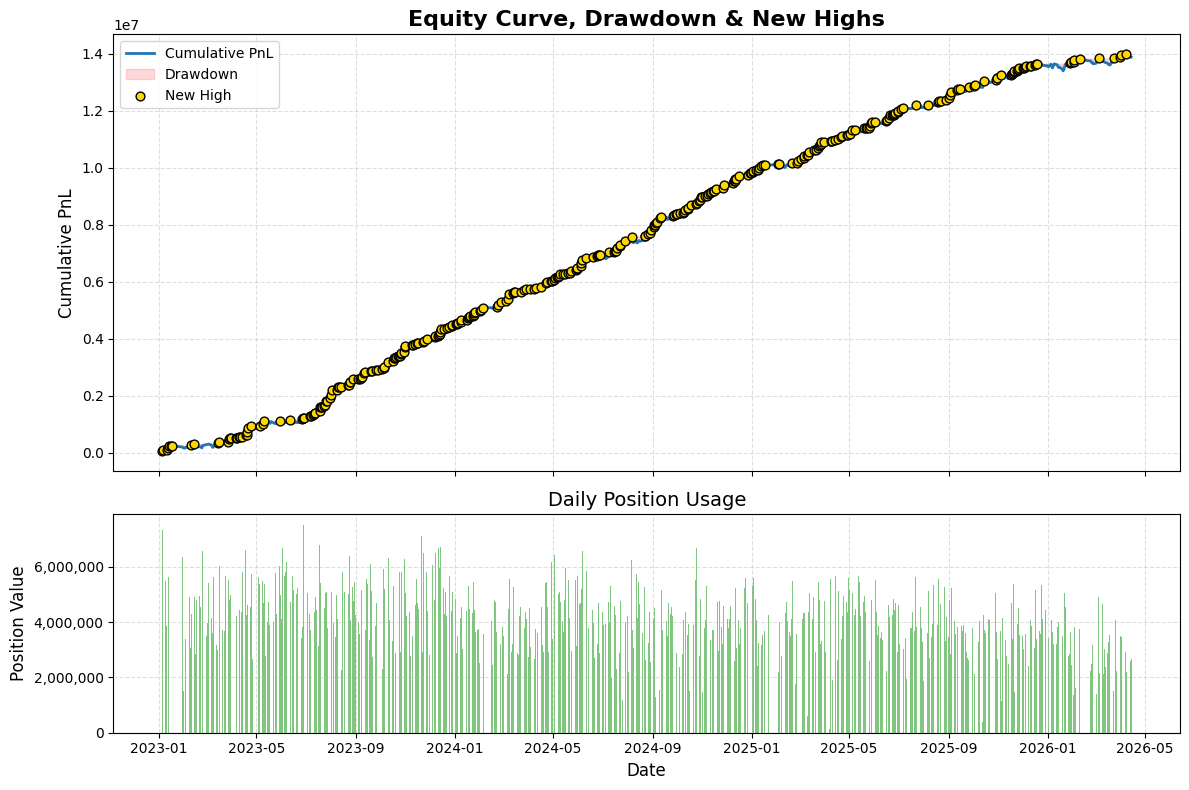


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 1,387.25
近一年報酬（萬）      : 287.85
風報比                  : 54.64
年化 Sharpe          : 5.86
創高最長費時 (天)     : 26
平均每日交易商品數   : 34.88

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 104.01%
近一年報酬率（近一年平均部位）: 79.51%
勝率 (日/單筆)      : 62.55% / 60.12%
平均BP (單/單位)   : 37.20 / 43.3364

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -16.65 萬
MDD金額/佔平均比   : -25.39 萬 / 6.23%
平均/最大部位(萬)  : 407.79 / 751.89
平均最大單一商品比  : 4.24%



In [35]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

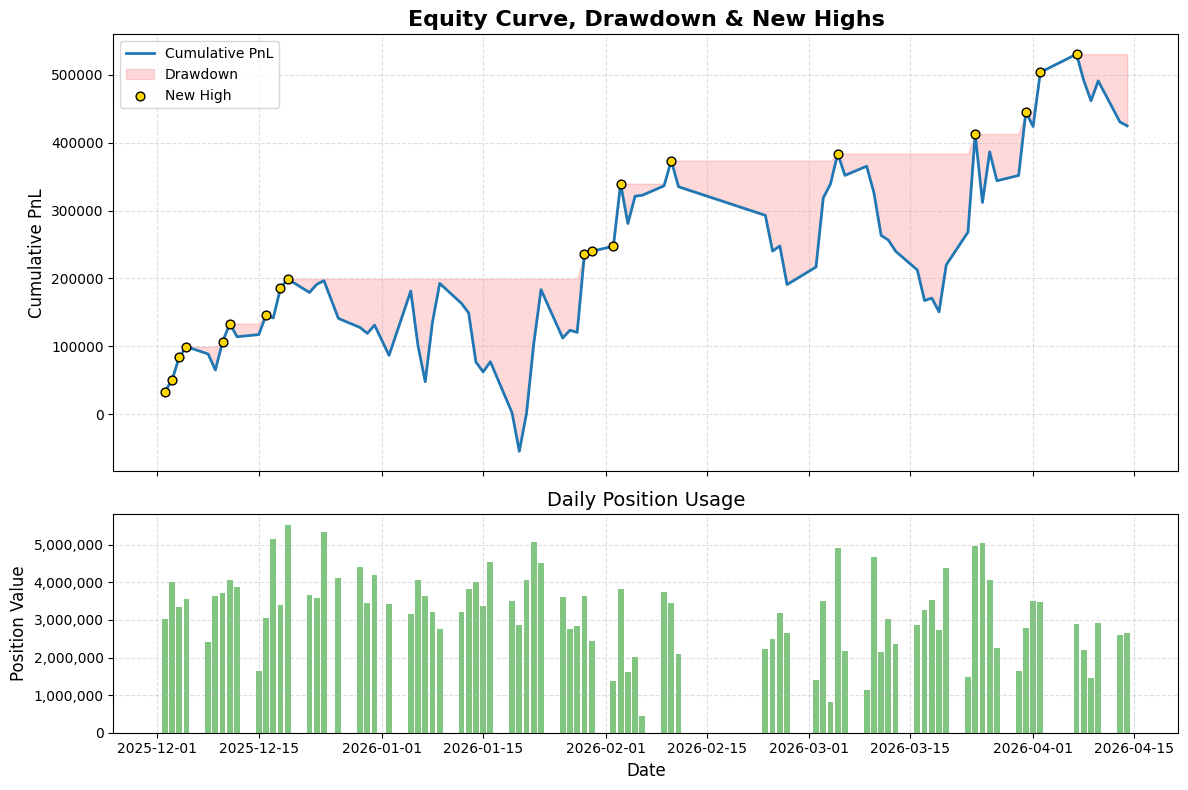


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 42.49
近一年報酬（萬）      : 42.49
風報比                  : 1.67
年化 Sharpe          : 1.58
創高最長費時 (天)     : 26
平均每日交易商品數   : 27.19

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 37.80%
近一年報酬率（近一年平均部位）: 13.23%
勝率 (日/單筆)      : 53.57% / 53.85%
平均BP (單/單位)   : 17.62 / 15.7515

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -10.09 萬
MDD金額/佔平均比   : -25.39 萬 / 7.91%
平均/最大部位(萬)  : 321.11 / 553.36
平均最大單一商品比  : 5.53%



In [36]:
bt = BackTest(signalwithRisk_df[signalwithRisk_df.Date.astype(int) > 20251201])
results = bt.run_analysis()

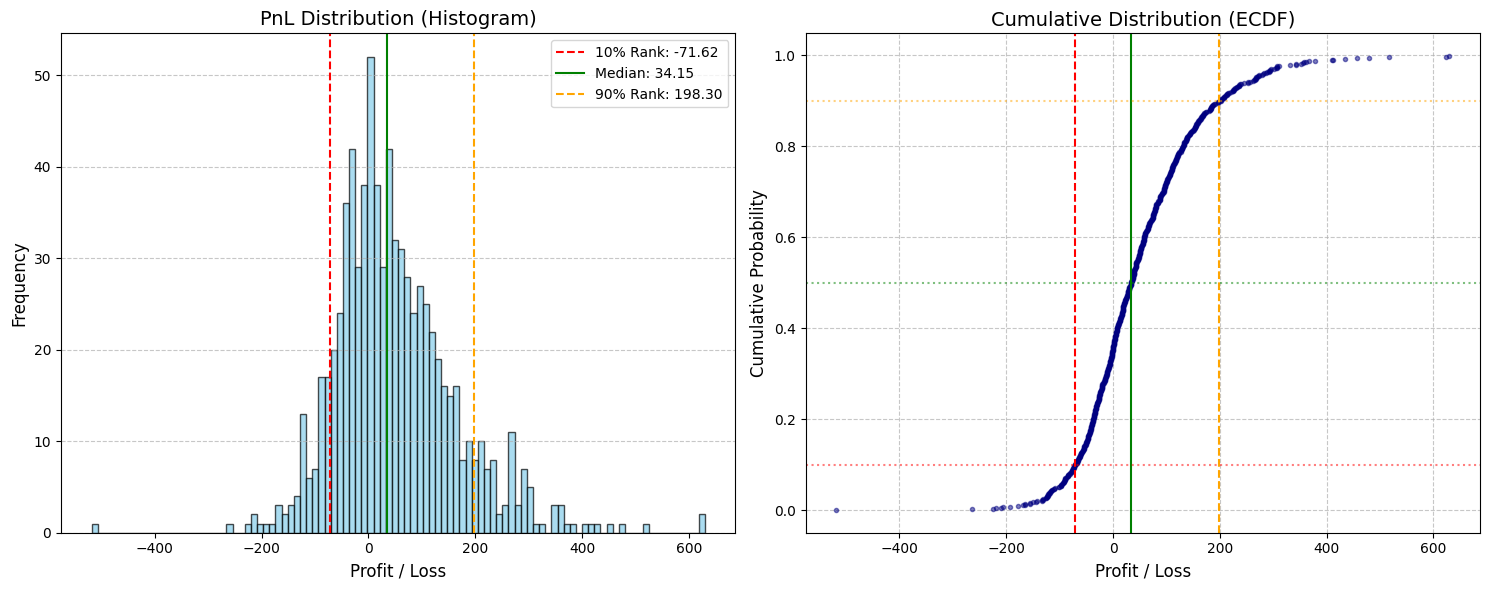

In [23]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [24]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [25]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [26]:
date_portfolio.describe()

,PL,Position,Return
count,785.000000,785.000000,785.000000
mean,49.984701,10334.438065,0.409891
std,115.301808,2700.658782,1.040590
min,-518.210559,198.650000,-4.532695
25%,-25.679604,8547.865000,-0.278314
50%,34.154703,10628.630000,0.336257
75%,109.896738,12208.645000,1.052624
max,629.678807,17682.380000,4.560848


In [27]:
date_portfolio.head()

,Date,PL,Position,Return
0,20230105,155.874939,14597.130,1.067846
1,20230106,-20.639509,10313.735,-0.200117
2,20230109,-88.483480,11523.565,-0.767848
3,20230110,43.081140,8732.570,0.493339
4,20230111,75.772217,10267.245,0.738000


In [28]:
df_0030_filtered

NameError: name 'df_0030_filtered' is not defined

【分析 A】2025 以後 兩者報酬與風險特性：
- 獲利率 Pearson 相關性: -0.5266
- 0030_portfolio  : 日波動 2.0241 | 年化波動度 32.1319
- date_portfolio  : 日波動 1.1154 | 年化波動度 17.7070

【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：
- 在 0030_portfolio 最差的 61 天中，有 6.56% 的機率 date_portfolio 也處於極端虧損
- 在 date_portfolio 最差的 61 天中，有 6.56% 的機率 0030 也處於極端虧損



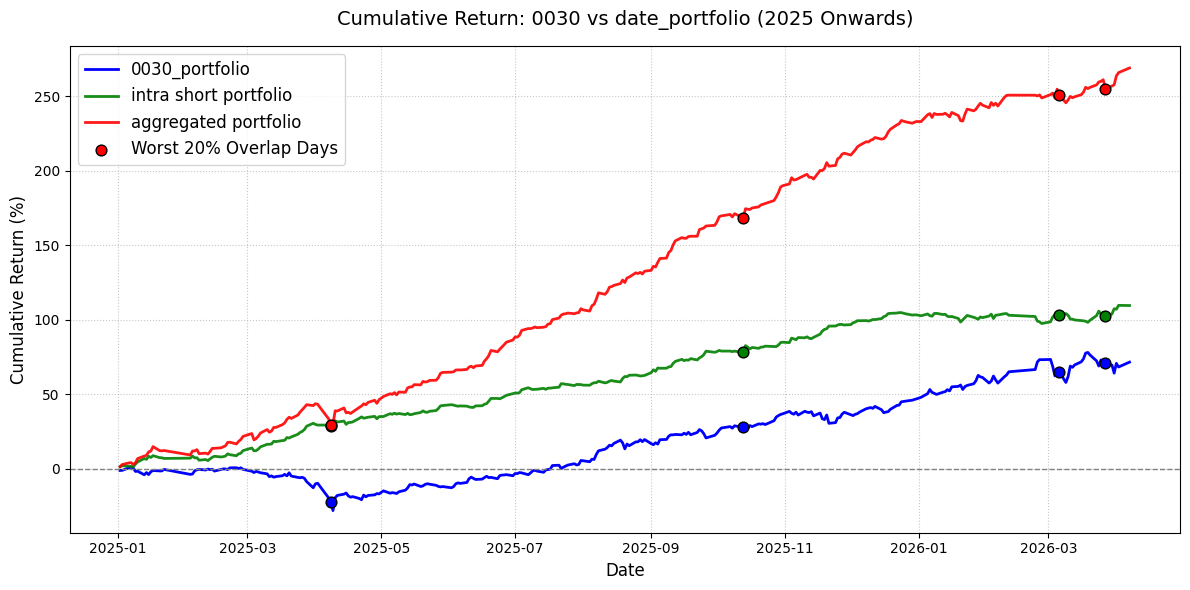

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. 讀取並處理 0030_portfolio.csv
# -------------------------------------------------------------------------
df_0030 = pd.read_csv('/home/kevin/Project/HFT/src/research/negFill/0030_portfolio.csv', encoding='utf-8-sig')

# 將 0030 的日期轉為 datetime 格式，方便後續篩選
df_0030['日期'] = pd.to_datetime(df_0030['日期'].astype(str), format='%Y%m%d')

# 👉 更正 1：篩選 2025 以後（包含 2025-01-01）
df_0030_filtered = df_0030[df_0030['日期'] >= '2025-01-01'].copy()
df_0030_filtered['獲利率'] = df_0030_filtered['獲利率'] * 100


# -------------------------------------------------------------------------
# 2. 處理 date_portfolio，對齊年份與格式
# -------------------------------------------------------------------------
# 👉 請確認這兩個變數對應您 date_portfolio 的實際欄位名稱：
date_col = 'Date'        # 日期欄位名稱
return_col = 'Return'    # 獲利率欄位名稱

dp_filtered = date_portfolio.copy()

# 若 date_portfolio 的日期在 index 上，請解除下面這行註解：
# dp_filtered = dp_filtered.reset_index() 

# 將該欄位轉為 datetime 格式，並篩選 2025 以後的資料
dp_filtered[date_col] = pd.to_datetime(dp_filtered[date_col].astype(str)) 
dp_filtered = dp_filtered[dp_filtered[date_col] >= '2025-01-01'].copy()


# -------------------------------------------------------------------------
# 合併兩者（取每日均有交易的交集日），並確保日期順序
# -------------------------------------------------------------------------
merged_df = pd.merge(
    df_0030_filtered[['日期', '獲利率']], 
    dp_filtered[[date_col, return_col]], 
    left_on='日期', 
    right_on=date_col, 
    how='inner'
)
merged_df = merged_df.sort_values('日期').reset_index(drop=True)


# =========================================================
# 分析 A：獲利率相關性與波動度
# =========================================================
correlation = merged_df['獲利率'].corr(merged_df[return_col])

# 👉 新增 2：計算波動度 (日標準差及乘上根號 252 的年化標準差)
vol_0030_daily = merged_df['獲利率'].std()
vol_0030_annual = vol_0030_daily * np.sqrt(252)

vol_dp_daily = merged_df[return_col].std()
vol_dp_annual = vol_dp_daily * np.sqrt(252)

print("【分析 A】2025 以後 兩者報酬與風險特性：")
print(f"- 獲利率 Pearson 相關性: {correlation:.4f}")
print(f"- 0030_portfolio  : 日波動 {vol_0030_daily:.4f} | 年化波動度 {vol_0030_annual:.4f}")
print(f"- date_portfolio  : 日波動 {vol_dp_daily:.4f} | 年化波動度 {vol_dp_annual:.4f}\n")


# =========================================================
# 分析 B：各自賠最多的 20% 交易日的重疊率 (基於原始 2025 以後的區間)
# =========================================================
thresh_0030 = df_0030_filtered['獲利率'].quantile(0.2)
thresh_dp = dp_filtered[return_col].quantile(0.2)

worst_days_0030 = set(df_0030_filtered[df_0030_filtered['獲利率'] <= thresh_0030]['日期'])
worst_days_dp = set(dp_filtered[dp_filtered[return_col] <= thresh_dp][date_col])

overlap_days = worst_days_0030.intersection(worst_days_dp)
union_days = worst_days_0030.union(worst_days_dp)

rate_0030 = len(overlap_days) / len(worst_days_0030) if len(worst_days_0030) > 0 else 0
rate_dp = len(overlap_days) / len(worst_days_dp) if len(worst_days_dp) > 0 else 0

print("【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：")
print(f"- 在 0030_portfolio 最差的 {len(worst_days_0030)} 天中，有 {rate_0030:.2%} 的機率 date_portfolio 也處於極端虧損")
print(f"- 在 date_portfolio 最差的 {len(worst_days_dp)} 天中，有 {rate_dp:.2%} 的機率 0030 也處於極端虧損\n")


# =========================================================
# 分析 C：繪製 2025 以後累計獲利率 (CumSum) 比較圖並標註重疊日
# =========================================================
# 計算 CumSum 與平均組合
merged_df['0030_cumsum'] = merged_df['獲利率'].cumsum()
merged_df['dp_cumsum'] = merged_df[return_col].cumsum()
merged_df['aggr_cumsum'] = (merged_df['0030_cumsum'] + merged_df['dp_cumsum']) / 2

plt.figure(figsize=(12, 6))

# 把累進獲利畫出來
plt.plot(merged_df['日期'], merged_df['0030_cumsum'], label='0030_portfolio', color='blue', linewidth=2)
plt.plot(merged_df['日期'], merged_df['dp_cumsum'], label='intra short portfolio', color='green', linewidth=2, alpha=0.9)
plt.plot(merged_df['日期'], (merged_df['0030_cumsum'] + merged_df['dp_cumsum']*1.8), label='aggregated portfolio', color='red', linewidth=2, alpha=0.9)

# ⭐️ 篩選出在「重疊天數」的那些資料點
overlap_df = merged_df[merged_df['日期'].isin(overlap_days)]

# ⭐️ 在這三條曲線上，把剛剛篩出來的點用實心圓圈標示出來 (zorder=5用來確保點畫在線條上方)
plt.scatter(overlap_df['日期'], overlap_df['0030_cumsum'], color='blue', s=60, marker='o', edgecolor='black', zorder=5)
plt.scatter(overlap_df['日期'], overlap_df['dp_cumsum'], color='green', s=60, marker='o', edgecolor='black', zorder=5)
plt.scatter(overlap_df['日期'],  (overlap_df['0030_cumsum'] + overlap_df['dp_cumsum']*1.8) , color='red', s=60, marker='o', edgecolor='black', zorder=5, label='Worst 20% Overlap Days')


# 圖表美化
plt.title('Cumulative Return: 0030 vs date_portfolio (2025 Onwards)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=1) # 補上 0 軸線方便看有沒有賺錢
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# 調整佈局並顯示
plt.tight_layout()
plt.show()


In [ ]:

from pathlib import Path
import os
PROJECT_ROOT = Path(os.path.abspath('')).parents[2]


dateData = []
for d in tqdm( date_portfolio.Date[:-1] ) : 
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d}_marketData.parquet')
    
    # 讀取 preMarketData (對應日期的每日特徵)
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d}_preMarketData.parquet')
    
    # 確保 key 都是字串型態以防合併錯誤
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    # 合併兩個 DataFrame
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    # 計算 toOpen
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    # 2. day_amount_rank < 100 的 mean
    top_df = merged_df[merged_df['day_amount_rank'] < 100]
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)
    
    dateData.append( [tsmcOpen, tsmcReturn, topOpen, topDrop, topReturn])
    # break


 87%|████████▋ | 680/779 [00:15<00:02, 42.80it/s]


KeyboardInterrupt: 

In [ ]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'topOpen', 'topDrop', 'topReturn'], data = dateData) ], axis = 1)

In [ ]:
date_portfolio= date_portfolio.reset_index(drop=True)

In [ ]:
date_portfolio['topStd_10D'] = (date_portfolio.topDrop).rolling(1,min_periods=1).min().shift()
date_portfolio['topReturnlast_10D'] = (date_portfolio.topOpen).rolling(10,min_periods=1).min().shift()

In [ ]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.002) | (date_portfolio.topReturnlast_10D < -0.035) 
# date_portfolio['Count'] =  (date_portfolio.topOpen < 0.00) | (date_portfolio.topReturnlast_10D < -0.025) 

In [ ]:
(date_portfolio.topOpen.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )

0      1.000000
1      0.500000
2      0.666667
3      0.500000
4      0.600000
         ...   
775    0.080000
776    0.130000
777    1.000000
778    0.860000
779         NaN
Name: topOpen, Length: 780, dtype: float64

In [ ]:
 (date_portfolio.topOpen.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )<0.3 

0      False
1      False
2      False
3      False
4      False
       ...  
775     True
776     True
777    False
778    False
779    False
Name: topOpen, Length: 780, dtype: bool

<Axes: >

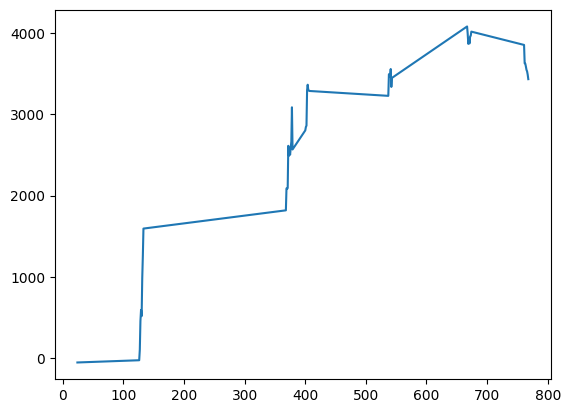

In [ ]:
# date_portfolio[ (date_portfolio.Count == 1) ].PL.cumsum().plot()
date_portfolio[ (date_portfolio.topReturnlast_10D.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )<0.05 ].PL.cumsum().plot()

<Axes: >

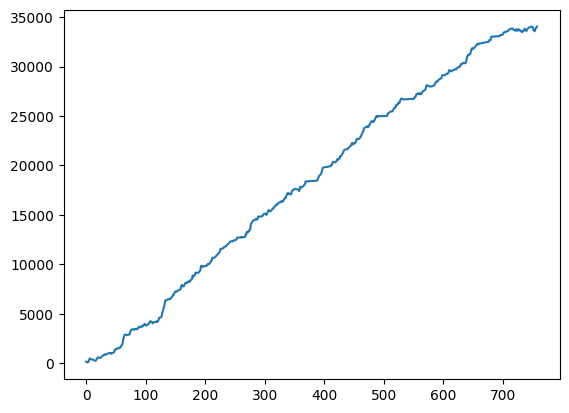

In [ ]:
date_portfolio[ date_portfolio.Count == 0 ].PL.cumsum().plot()

In [ ]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==True) ].Date

In [ ]:
abonraml_DATE

1      20230106
3      20230110
8      20230117
10     20230131
13     20230203
         ...   
775    20260330
776    20260331
777    20260401
778    20260402
779    20260407
Name: Date, Length: 324, dtype: str

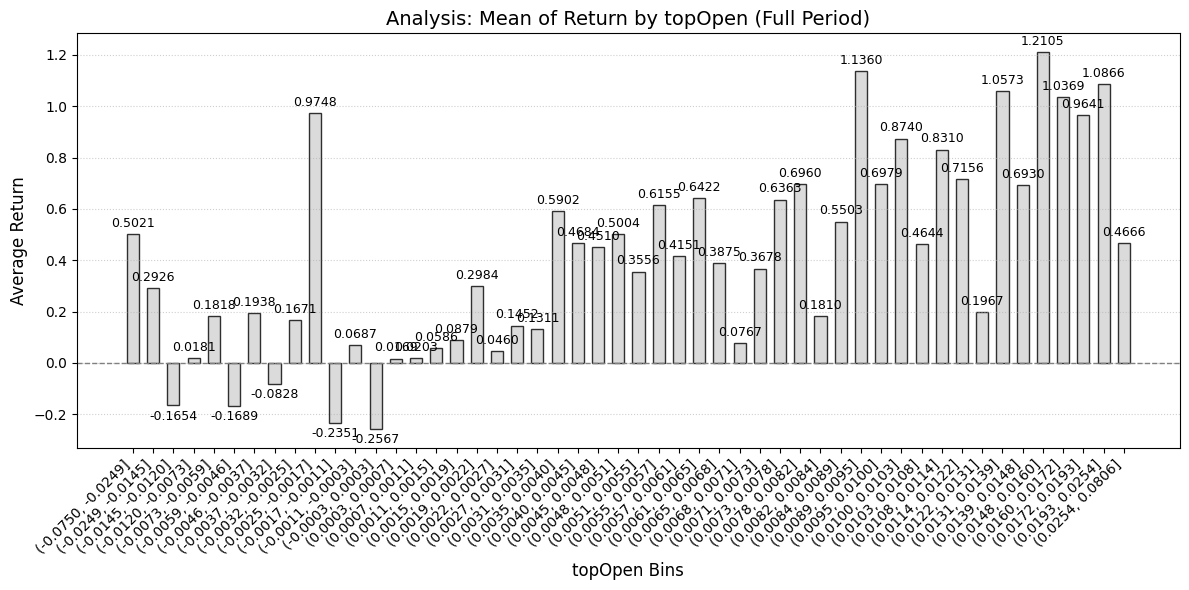

In [ ]:
plot_qcut_analysis(date_portfolio, col_a='topOpen', col_b=f'Return', q=50 , isMin=False)
# plot_qcut_analysis(date_portfolio, col_a='topStd_10D', col_b=f'Return', q=50 , isMin=True)

In [ ]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'